Run this notebook for sim = 0, 1, 2, ..., 9 to fit the 10 simulated images.

In [1]:
sim = 0

In [2]:
import numpy as np
import corner
import astropy.io.fits as pyfits
import matplotlib.pyplot as plt

# lenstronomy imports
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.LensModel.lens_model import LensModel
import lenstronomy.Util.simulation_util as sim_util
from lenstronomy.Util import kernel_util
import lenstronomy.Util.util as util

np.random.seed(40)

In [3]:
data_image_set = np.load("sim_image_noisy_set.npy")
data_image = data_image_set[sim]

pb_sim = pyfits.getdata("..//fits//sim_noise1.pb.fits")
pb_sim = pb_sim[0][0]
pb_sim = np.nan_to_num(pb_sim)

psf_sim = pyfits.getdata("..//fits//sim_noise1.psf.fits")
psf_sim = psf_sim[0][0]
psf_sim=np.nan_to_num(psf_sim)

In [4]:
pb_cut = pb_sim[50:150, 50:150] * 0.9  # use a pb of values smaller than 1 to test the pb implementation
psf_pixel = psf_sim[150:351,150:351]

In [5]:
background_rms = 1e-4
exp_time = np.inf  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 100  #  cutout pixel size
deltaPix = 0.035  #  pixel size in arcsec (area per pixel = deltaPix**2)
psf_type = 'PIXEL'  # 'gaussian', 'pixel', 'NONE'
kernel_size = 201  # PSF kernel size (odd number required).

# initial input simulation
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
# generate the coordinate grid and image properties
kwargs_data = sim_util.data_configure_simple(numPix, deltaPix, exp_time, background_rms)
kwargs_data['ra_at_xy_0'] = -(50)*deltaPix
kwargs_data['dec_at_xy_0'] = -(50)*deltaPix
kwargs_data['antenna_primary_beam'] = pb_cut
kwargs_data['likelihood_method'] = 'interferometry_natwt'
kwargs_data['image_data'] = data_image

# generate the psf variables
kernel_cut = kernel_util.cut_psf(psf_pixel, kernel_size, normalisation=False)
kwargs_psf = {'psf_type': psf_type, 'pixel_size': deltaPix,
                    'kernel_point_source': kernel_cut, 'kernel_point_source_normalisation': False}
psf_class = PSF(**kwargs_psf)
data_class = ImageData(**kwargs_data)

kwargs_numerics = {'supersampling_convolution': False}

C:\Users\Administrator\AppData\Roaming\Python\Python38\site-packages\lenstronomy\Data\psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(


In [6]:
single_band = [[kwargs_data, kwargs_psf, kwargs_numerics]]
kwargs_data_joint = {'multi_band_list': single_band, 'multi_band_type': 'multi-linear'}

point_source_model_list = ['UNLENSED']

kwargs_fixed_ps = []
kwargs_ps_init = []
kwargs_ps_sigma = []
kwargs_lower_ps = []
kwargs_upper_ps = []

kwargs_fixed_ps.append({})
kwargs_ps_init.append({
   'ra_image': [-0.28, -1.33, 0.87, -0.64, -0.15],
   'dec_image': [0.41, -0.41, 1.3, 0.13, -0.55]})
kwargs_ps_sigma.append({
    'ra_image': [0.3]*5,
   'dec_image': [0.3]*5})
kwargs_lower_ps.append({
   'ra_image': [-1.7]*5,
   'dec_image': [-1.7]*5})
kwargs_upper_ps.append({
   'ra_image': [1.7]*5,
   'dec_image': [1.7]*5})

ps_params = [kwargs_ps_init, kwargs_ps_sigma, kwargs_fixed_ps, kwargs_lower_ps, kwargs_upper_ps]


kwargs_params = {'point_source_model': ps_params}

kwargs_model = {'point_source_model_list': point_source_model_list}
kwargs_likelihood = {}
kwargs_constraints = {'num_point_source_list': [5]}

from lenstronomy.Workflow.fitting_sequence import FittingSequence
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params, mpi=False)

fitting_kwargs_list =[['PSO', {'sigma_scale': 0.99, 'n_particles': 200, 'n_iterations': 1000, 'threadCount': 1}],
                     ['MCMC', {'n_burn': 700, 'n_run': 300, 'n_walkers':100, 'sigma_scale': 0.02, 'threadCount':1}]]

In [7]:
chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_result = fitting_seq.best_fit()

C:\Users\Administrator\AppData\Roaming\Python\Python38\site-packages\lenstronomy\Data\psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(
  0%|          | 0/1000 [00:00<?, ?it/s]

Computing the PSO ...


 10%|█         | 104/1000 [12:56<1:51:25,  7.46s/it]


Converged after 104 iterations!
Best fit found:  3670.8342950389233 [-0.2849341877686135, -1.325609882649469, 0.8672379755047371, -0.6457054764218663, -0.14328920369438136, 0.41879755845995004, -0.40749428796155723, 1.2902096445122313, 0.12833240732471923, -0.551242758277104]
0.7352697636532646 reduced X^2 of best position
3670.8342950389233 log likelihood
9985.0 effective number of data points
[] lens result
[] source result
[] lens light result
[{'ra_image': array([-0.28493419, -1.32560988,  0.86723798, -0.64570548, -0.1432892 ]), 'dec_image': array([ 0.41879756, -0.40749429,  1.29020964,  0.12833241, -0.55124276]), 'point_amp': array([1., 1., 1., 1., 1.])}] point source result
[] tracer source result
{} special param result
776.0232048034668 time used for  PSO
MCMC selected. Sampling with default option emcee.


100%|██████████| 1000/1000 [1:01:33<00:00,  3.69s/it]

Computing the MCMC...
Number of walkers =  100
Burn-in iterations:  700
Sampling iterations (in current run): 1000
3698.685903072357 time taken for MCMC sampling


In [8]:
sampler_type, samples_mcmc, param_mcmc, dist_mcmc  = chain_list[-1]

In [9]:
param_mcmc

['ra_image',
 'ra_image',
 'ra_image',
 'ra_image',
 'ra_image',
 'dec_image',
 'dec_image',
 'dec_image',
 'dec_image',
 'dec_image']

<ipython-input-10-0e0c120cbb23>:3: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plot.show()


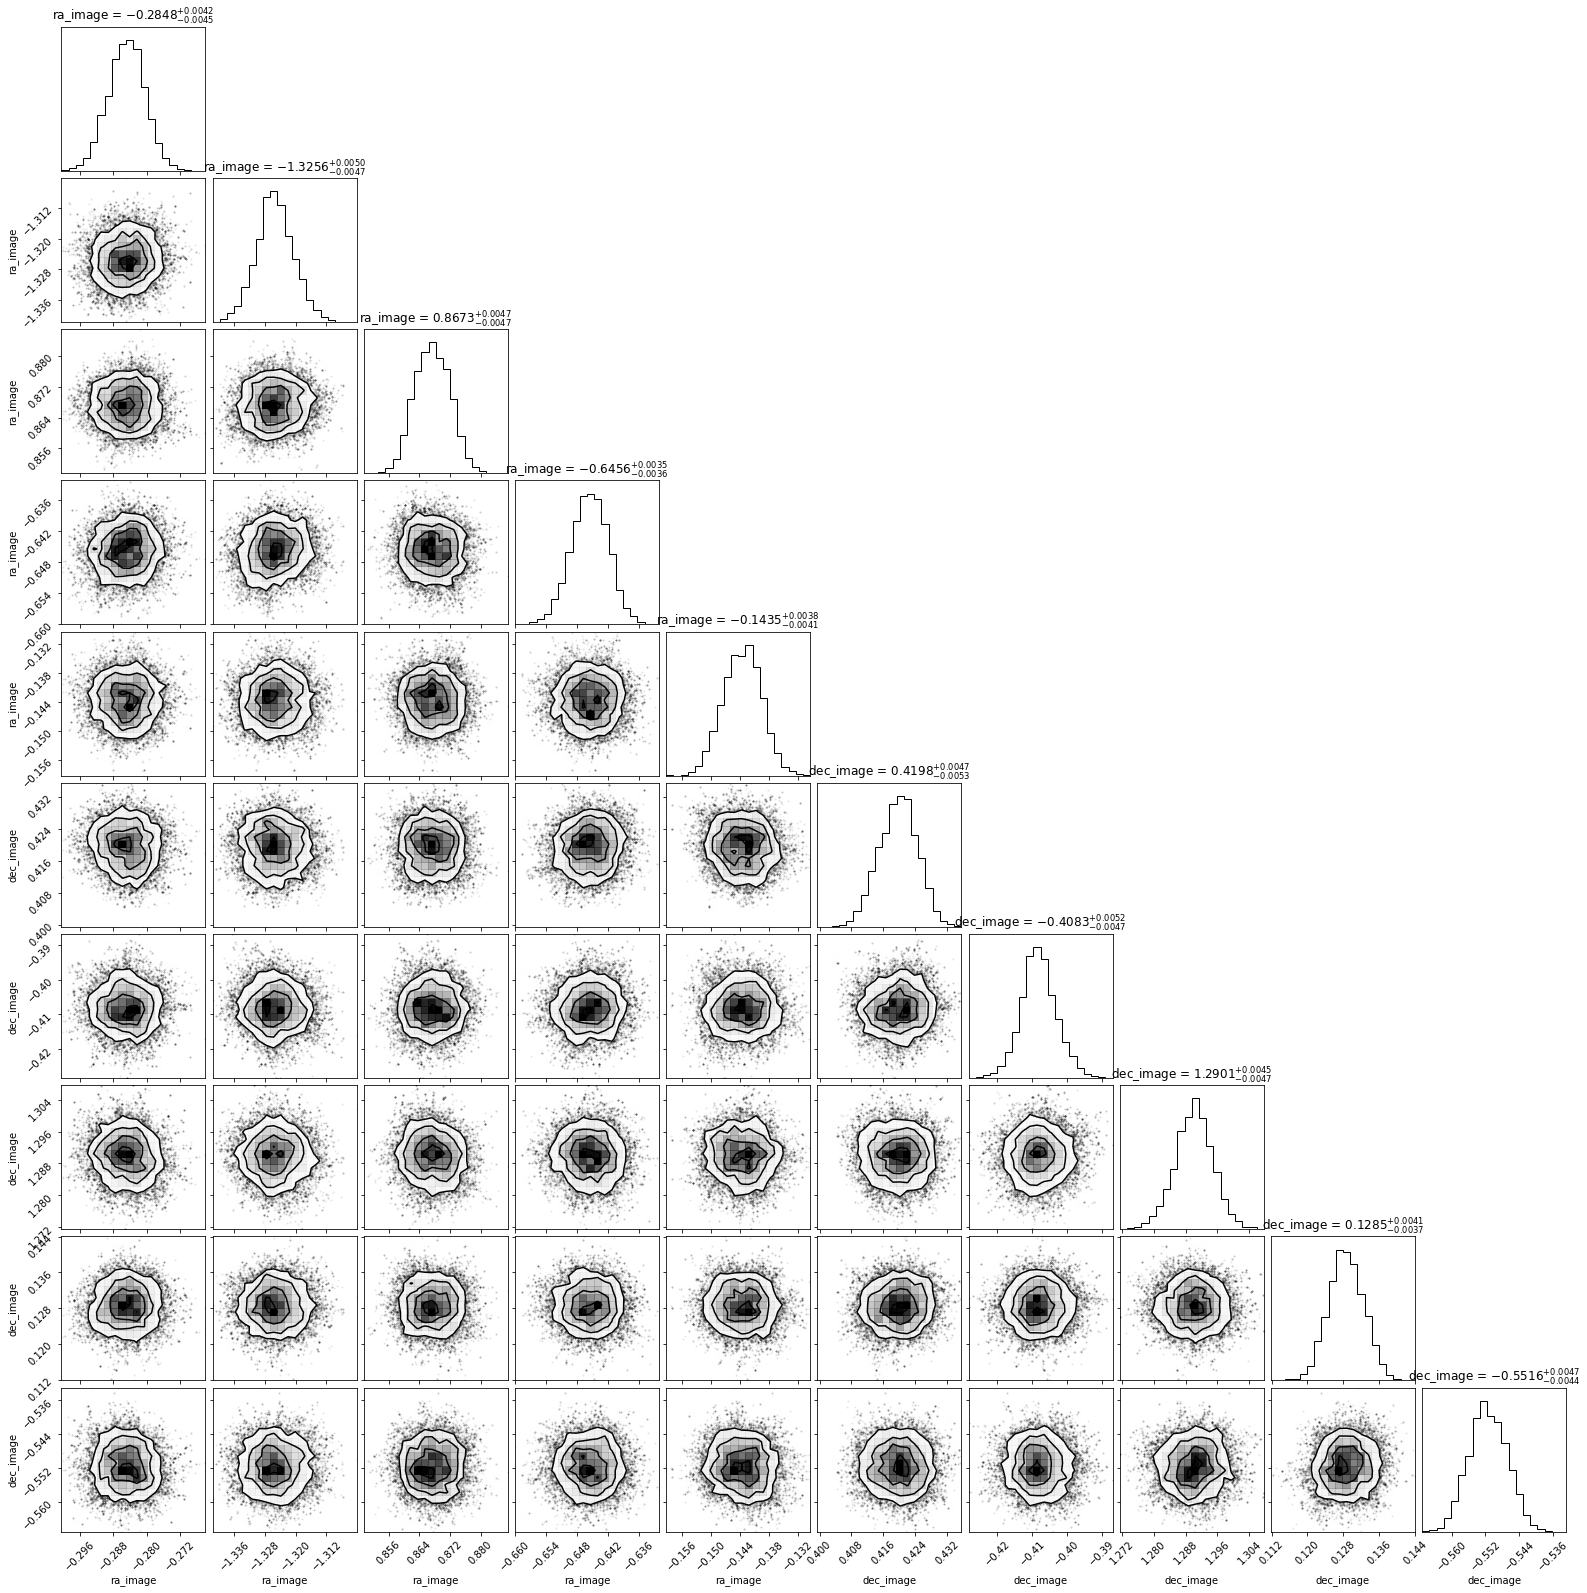

In [10]:
import corner
plot = corner.corner(samples_mcmc, labels=param_mcmc, show_titles=True, title_fmt = ".4f")
plot.show()

In [11]:
import h5py

In [12]:
with h5py.File('fitting results//chain_fitting_unlensed_ps_sim' + str(sim) + '.h5', 'w') as fh5:
    fh5.create_dataset('chain', data=samples_mcmc, compression='gzip', compression_opts=9)